# Explore here

**Predecir el coste del seguro médico de una persona**

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

In [1]:
from sqlalchemy.orm import declarative_base
from sqlalchemy import String
from sqlalchemy.orm import Mapped, mapped_column

Base = declarative_base()

class ExampleModel(Base):
    __tablename__ = 'example_table'
    id: Mapped[int] = mapped_column(primary_key=True)
    username: Mapped[str] = mapped_column(unique=True)

In [2]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')
# Display the first few rows of the dataset
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


- age. Edad del beneficiario principal (numérico)
- sex. Género del beneficiario principal (categórico)
- bmi. índice de masa corporal (numérico)
- children. Número de niños/dependientes cubiertos por un seguro médico (numérico)
- smoker. ¿Es fumador? (categórico)
- region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
- charges. Prima del seguro médico (numérico)

In [3]:
df.shape

(1338, 7)

In [4]:
pd.isnull(df).sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(1337, 7)

Separamos variables numéricas de categóricas para el análisis univariado. 

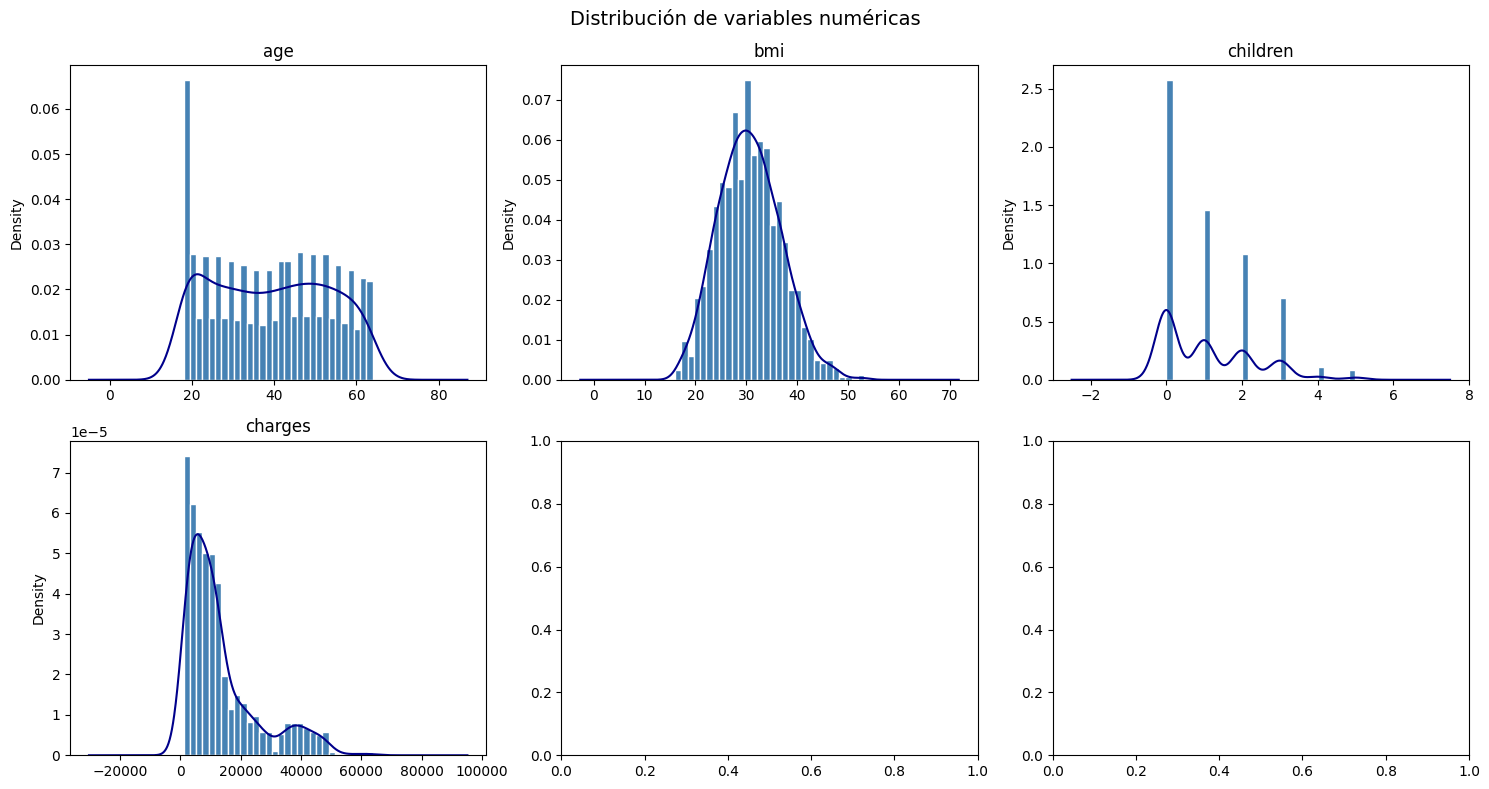

In [10]:
#variables numéricas
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', bins=30, ax=axes[i], color='steelblue', edgecolor='white', density=True)
    df[col].plot(kind='kde', ax=axes[i], color='darkblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/kh/l_sgt06d6wx2bx8vhlf521c40000gn/T/ipykernel_28877/1852588990.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


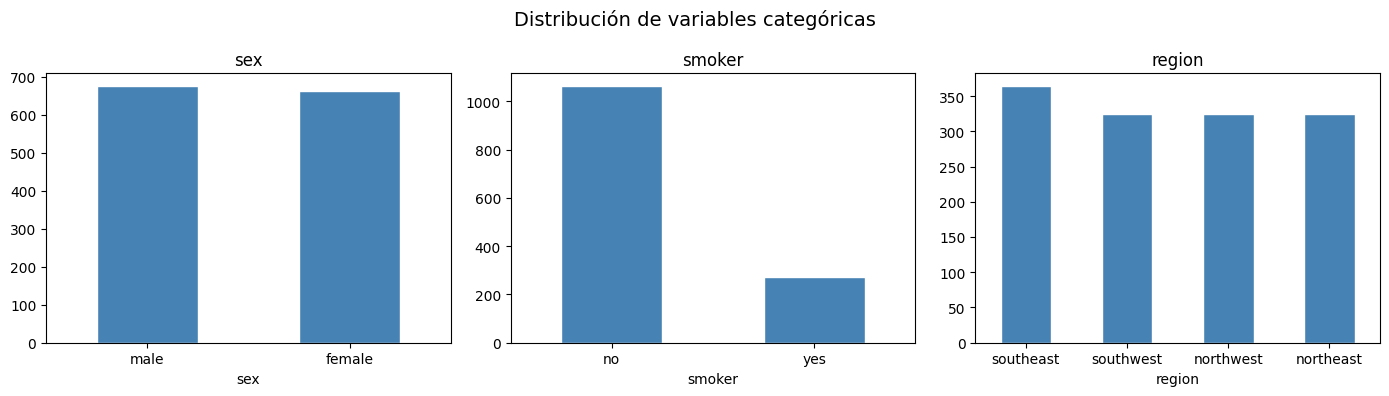

In [11]:
#variables categoricas
cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribución de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

Análisis multivariado: relacionar distintas variables

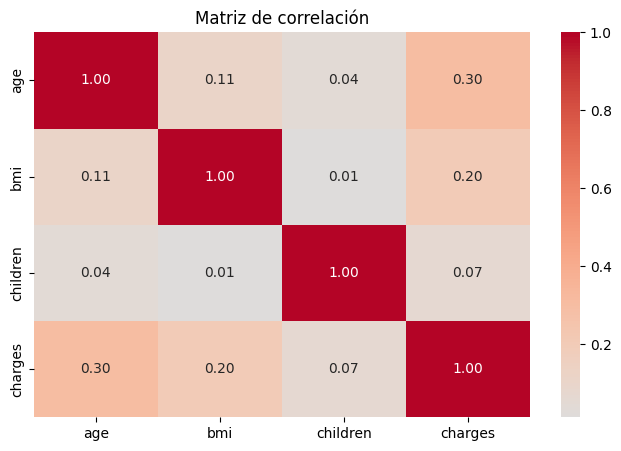

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

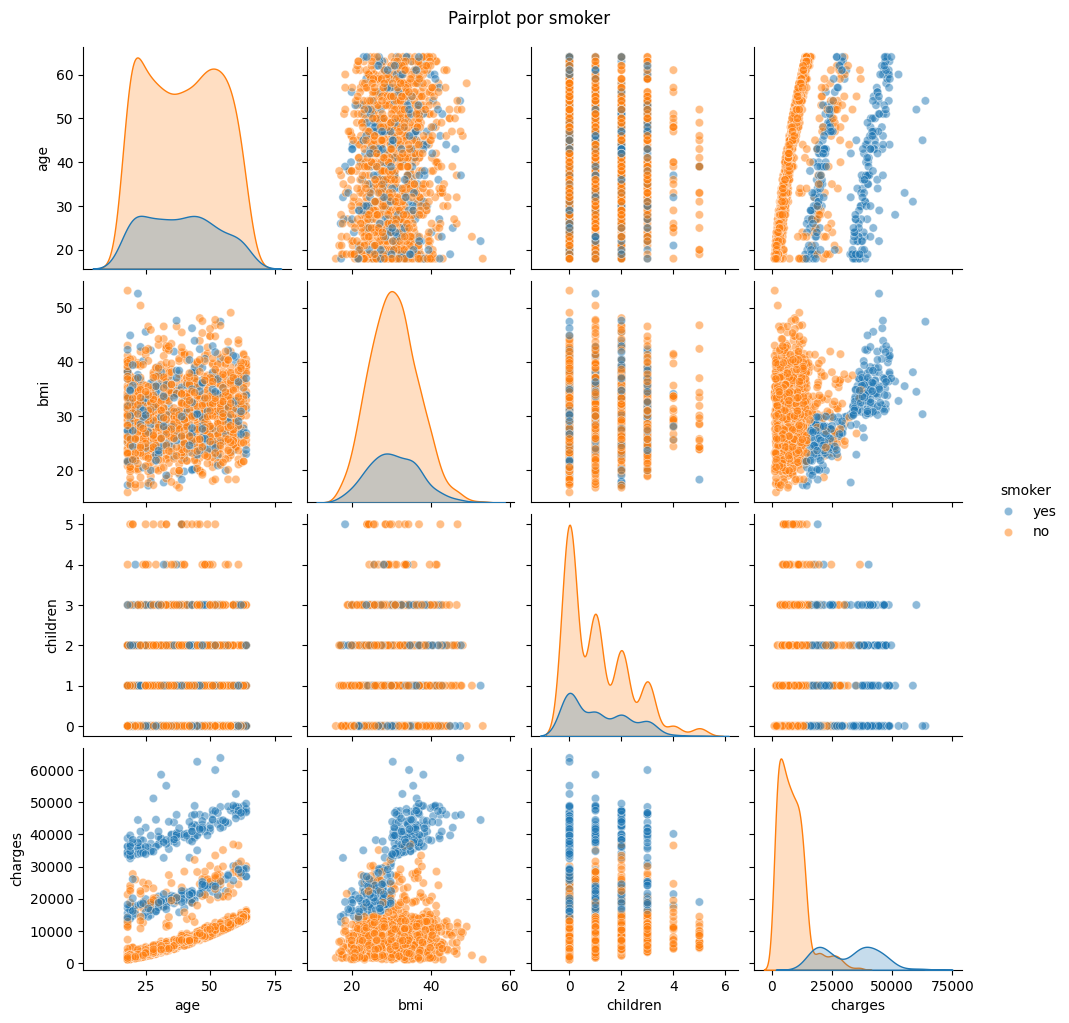

In [13]:
sns.pairplot(df, hue='smoker', vars=['age', 'bmi', 'children', 'charges'], 
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot por smoker', y=1.02)
plt.show()

/var/folders/kh/l_sgt06d6wx2bx8vhlf521c40000gn/T/ipykernel_28877/3502232539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='Set2')
/var/folders/kh/l_sgt06d6wx2bx8vhlf521c40000gn/T/ipykernel_28877/3502232539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='Set2')
/var/folders/kh/l_sgt06d6wx2bx8vhlf521c40000gn/T/ipykernel_28877/3502232539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette=

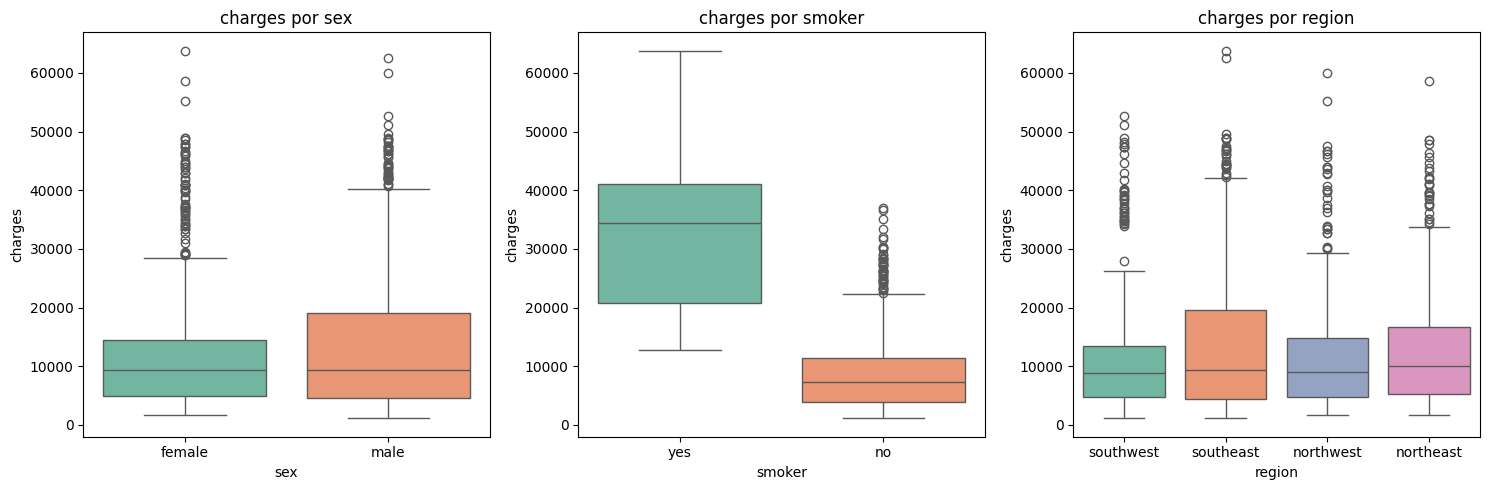

In [14]:
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='Set2')
    axes[i].set_title(f'charges por {col}')

plt.tight_layout()
plt.show()

Con estos graficos podemos ver claramente que:
- `smoker` tiene la correlación más fuerte con `charges`: lo que quiere decir que los fumadores pagan muchísimo más
- `age` y `bmi` también correlacionan positivamente con charges: por lo tanto también afectan a lo que pagan
- `sex` y `region` apenas muestran diferencia: no son tan relevantes a la hora de fijar el precio

**Transformaciones**

In [15]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [16]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [17]:
df.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [18]:
pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
df.corr()['charges'].sort_values(ascending=False)

charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

In [20]:
df.drop(columns=['sex', 'children', 'region_northwest', 'region_southwest', 'region_southeast'], inplace=True)

In [21]:
df.shape

(1337, 4)

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='charges')
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1069, 3) (268, 3)


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred) # R² te dice qué porcentaje de la varianza de charges explica el modelo — cuanto más cerca de 1 mejor

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

RMSE: 5986.78
R²: 0.8050


- El 80% de la varianza en el coste de la prima 
- El RMSE de 5986 significa que el modelo se equivoca de media en unos 6000$ por predicción

Paso 4. Optimización

In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.2, max_iter=400)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("RMSE Ridge:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Ridge:", r2_score(y_test, y_pred_ridge))

RMSE Ridge: 5989.578074999795
R² Ridge: 0.8047681000149506


In [25]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.2, max_iter=400)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("RMSE Lasso:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R² Lasso:", r2_score(y_test, y_pred_lasso))

RMSE Lasso: 5986.916614582338
R² Lasso: 0.804941563496129


In [26]:
#Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [rmse, np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 
             np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
    'R²': [r2, r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
})
print(resultados)

              Modelo         RMSE        R²
0  Linear Regression  5986.783345  0.804950
1              Ridge  5989.578075  0.804768
2              Lasso  5986.916615  0.804942


Aplicamos tecnicas de regularización Lasso y Ridge, pero el modelo base ya está bien ajustado y no hay sobreajuste significativo 

Esto te permite ver de forma intuitiva cómo el modelo diferencia entre perfiles — un joven no fumador con bmi normal vs un mayor fumador con sobrepeso. La diferencia en la prima debería ser bastante grande

In [ ]:
#ejemplo de predicción: 
pacientes = pd.DataFrame({
    'age': [25, 45, 60],
    'bmi': [22.0, 30.5, 35.0],
    'smoker': [0, 1, 0]  # 0 = no fumador, 1 = fumador
})

predicciones = model.predict(pacientes)

pacientes['prima_estimada'] = predicciones.round(2)
print(pacientes)

   age   bmi  smoker  prima_estimada
0   25  22.0       0         2231.67
1   45  30.5       1        32934.28
2   60  35.0       0        15009.77
